# QuantJourney SDK - CBOE VIX Volatility Index

This notebook demonstrates CBOE data:
- VIX Fear Index (current and historical)
- Volatility analysis
- Fear/Greed zones

**API:** https://api.quantjourney.cloud

## Preview Chart

![08_cboe_vix](../outputs/candidates/08_cboe_vix.png)

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

from quantjourney.sdk import QuantJourneyAPI
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png"

import plotly.graph_objects as go

# API Key authentication
import os
API_KEY = os.environ.get("QJ_API_KEY", "qj_...")

qj = QuantJourneyAPI(api_key=API_KEY)
print("✓ Connected to QuantJourney API")


✓ Connected to QuantJourney API


## 1. VIX Historical Data (CBOE)

In [2]:
# Fetch VIX historical data from CBOE
from datetime import datetime, timedelta

end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

try:
    response = qj.cboe.get_vix_data(
        start_date=start_date,
        end_date=end_date,
        interval="1d"
    )
    vix_data = response.get('value', response) if isinstance(response, dict) else response
    
    if vix_data:
        df_vix_cboe = pd.DataFrame(vix_data)
        print(f"VIX records from CBOE: {len(df_vix_cboe)}")
        print(f"\nColumns: {list(df_vix_cboe.columns)}")
        print(f"\nLatest VIX data:")
        print(df_vix_cboe.tail())
except Exception as e:
    print(f"Note: CBOE VIX data - {e}")


VIX records from CBOE: 258

Columns: ['date', 'volume', 'open', 'high', 'low', 'close']

Latest VIX data:
           date volume       open       high        low      close
253  2026-01-16    0.0  15.440000  16.290000  15.300000  15.860000
254  2026-01-19    0.0  18.630000  19.590000  18.280000  18.840000
255  2026-01-20    0.0  19.940000  20.990000  18.640000  20.090000
256  2026-01-21    0.0  19.310000  20.810000  16.670000  16.900000
257  2026-01-22    0.0  16.650000  16.670000  15.270000  15.640000


## 2. VIX Historical (via EOD)

In [3]:
# VIX historical data using EOD connector
try:
    response = qj.eod.get_historical_prices(
        symbol="VIX.INDX",
        start_date="2020-01-01",
        end_date="2025-12-31",
        frequency="1d"
    )
    vix_hist = response.get('value', response) if isinstance(response, dict) else response
    
    if vix_hist:
        df_vix = pd.DataFrame(vix_hist)
        df_vix['date'] = pd.to_datetime(df_vix['date'])
        df_vix = df_vix.sort_values('date')
        
        print(f"VIX records: {len(df_vix)}")
        print(f"Date range: {df_vix['date'].min().date()} to {df_vix['date'].max().date()}")
        print(f"\nLatest values:")
        print(df_vix[['date', 'open', 'high', 'low', 'close']].tail())
except Exception as e:
    print(f"Note: VIX historical - {e}")


VIX records: 1536
Date range: 2020-01-02 to 2025-12-31

Latest values:
           date   open   high    low  close
1531 2025-12-25  13.47  13.47  13.47  13.47
1532 2025-12-26  14.12  14.29  13.52  13.60
1533 2025-12-29  14.69  15.08  13.99  14.20
1534 2025-12-30  14.43  14.62  14.04  14.33
1535 2025-12-31  14.77  15.17  14.38  14.95


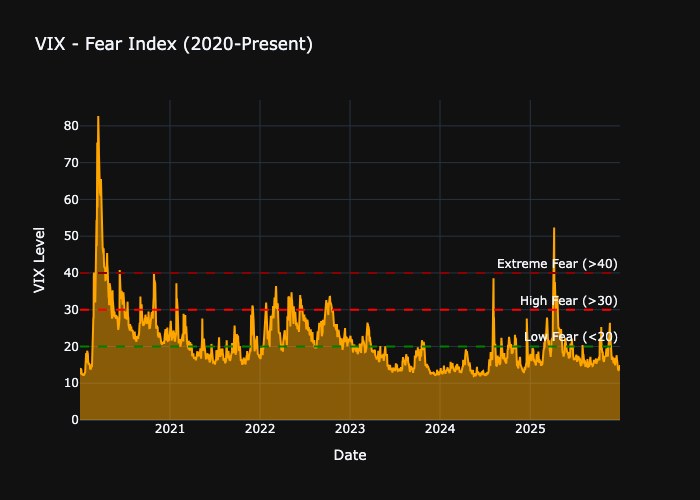


VIX Analysis:
  Current:   14.9
  Average:   20.9
  Median:    19.0
  Max Spike: 82.7
  Min:       11.9
  Sentiment: Extreme Complacency


In [5]:
# Plot VIX Fear Index
if 'df_vix' in dir() and len(df_vix) > 0:
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=df_vix['date'],
        y=df_vix['close'],
        fill='tozeroy',
        name='VIX',
        line=dict(color='orange')
    ))
    
    # Add fear/greed zones
    fig.add_hline(y=20, line_dash='dash', line_color='green', 
                  annotation_text='Low Fear (<20)')
    fig.add_hline(y=30, line_dash='dash', line_color='red', 
                  annotation_text='High Fear (>30)')
    fig.add_hline(y=40, line_dash='dash', line_color='darkred', 
                  annotation_text='Extreme Fear (>40)')
    
    fig.update_layout(
        title='VIX - Fear Index (2020-Present)',
        yaxis_title='VIX Level',
        xaxis_title='Date',
        template='plotly_dark',
        height=500
    )
    fig.show()
    
    # Statistics
    print(f"\nVIX Analysis:")
    print(f"  Current:   {df_vix['close'].iloc[-1]:.1f}")
    print(f"  Average:   {df_vix['close'].mean():.1f}")
    print(f"  Median:    {df_vix['close'].median():.1f}")
    print(f"  Max Spike: {df_vix['close'].max():.1f}")
    print(f"  Min:       {df_vix['close'].min():.1f}")
    
    # Current sentiment
    current = df_vix['close'].iloc[-1]
    if current < 15:
        sentiment = "Extreme Complacency"
    elif current < 20:
        sentiment = "Low Fear"
    elif current < 30:
        sentiment = "Moderate Fear"
    elif current < 40:
        sentiment = "High Fear"
    else:
        sentiment = "Extreme Fear/Panic"
    print(f"  Sentiment: {sentiment}")


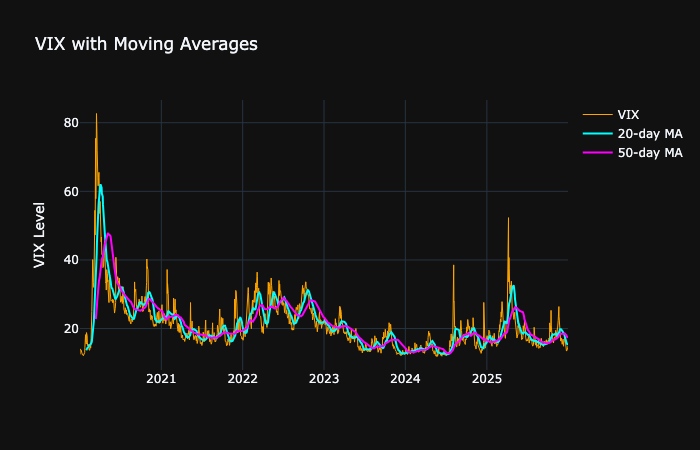


VIX Regime Distribution:
  Low Vol (<20):     56.0%
  Medium (20-30):    34.4%
  High Vol (>30):    9.6%


In [6]:
# VIX distribution and regime analysis
if 'df_vix' in dir() and len(df_vix) > 0:
    # Calculate rolling statistics
    df_vix['vix_ma20'] = df_vix['close'].rolling(20).mean()
    df_vix['vix_ma50'] = df_vix['close'].rolling(50).mean()
    df_vix['vix_std20'] = df_vix['close'].rolling(20).std()
    
    # Plot with moving averages
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=df_vix['date'],
        y=df_vix['close'],
        name='VIX',
        line=dict(color='orange', width=1)
    ))
    
    fig.add_trace(go.Scatter(
        x=df_vix['date'],
        y=df_vix['vix_ma20'],
        name='20-day MA',
        line=dict(color='cyan', width=2)
    ))
    
    fig.add_trace(go.Scatter(
        x=df_vix['date'],
        y=df_vix['vix_ma50'],
        name='50-day MA',
        line=dict(color='magenta', width=2)
    ))
    
    fig.update_layout(
        title='VIX with Moving Averages',
        yaxis_title='VIX Level',
        template='plotly_dark',
        height=450
    )
    fig.show()
    
    # Regime breakdown
    low_vol = (df_vix['close'] < 20).sum() / len(df_vix) * 100
    mid_vol = ((df_vix['close'] >= 20) & (df_vix['close'] < 30)).sum() / len(df_vix) * 100
    high_vol = (df_vix['close'] >= 30).sum() / len(df_vix) * 100
    
    print(f"\nVIX Regime Distribution:")
    print(f"  Low Vol (<20):     {low_vol:.1f}%")
    print(f"  Medium (20-30):    {mid_vol:.1f}%")
    print(f"  High Vol (>30):    {high_vol:.1f}%")


## Summary

CBOE VIX data covered:
- **Current VIX**: Real-time fear gauge
- **Historical VIX**: Long-term volatility trends
- **VIX Fear**: Treshold volatility plots
- **Regime Analysis**: Low/Medium/High volatility periods

### VIX Interpretation:
- **< 15**: Extreme complacency (potential top)
- **15-20**: Low fear, bullish sentiment
- **20-30**: Normal/elevated uncertainty
- **30-40**: High fear, potential opportunity
- **> 40**: Panic selling, capitulation